# Extra baselines — Sven vs the full optimizer suite

Reviewer-requested modern optimizers on the headline datasets (full data). Best final loss per method; does the wider comparison change the story?

> Loads the fresh Gram-backend results. Robust to partial data (plots whatever has finished).

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from style import load_results, average_over_seeds, set_style
from analysis_helpers import add_derived, best_per_method, valid, loss_curve, steps_to_target, method_order
from pathlib import Path
set_style()
PLOT_DIR = Path('plots/baselines'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
def sven_color(m): return 'k' if m=='Sven' else None
def sven_lw(m):    return 2.6 if m=='Sven' else 1.6

In [2]:
SCANS = {'toy_1d':'rebuttal_baselines_toy_1d_scan','polynomial':'polynomial_scan',
         'mnist':'mnist_scan_labelRegression'}
data={}
for tag,name in SCANS.items():
    try: data[tag]=add_derived(load_results(name))
    except FileNotFoundError: print('missing',name)

Loaded 1184 runs from ../experiment_results/rebuttal_baselines_toy_1d_scan/ (directory format)
Loaded 1180 runs from ../experiment_results/rebuttal_baselines_polynomial_scan/ (directory format)
Loaded 303 runs from ../experiment_results/rebuttal_baselines_mnist_scan/ (directory format)


### Best final loss per optimizer

findfont: Font family 'arial' not found.
findfont: Font family ['arial'] not found. Falling back to DejaVu Sans.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'ari

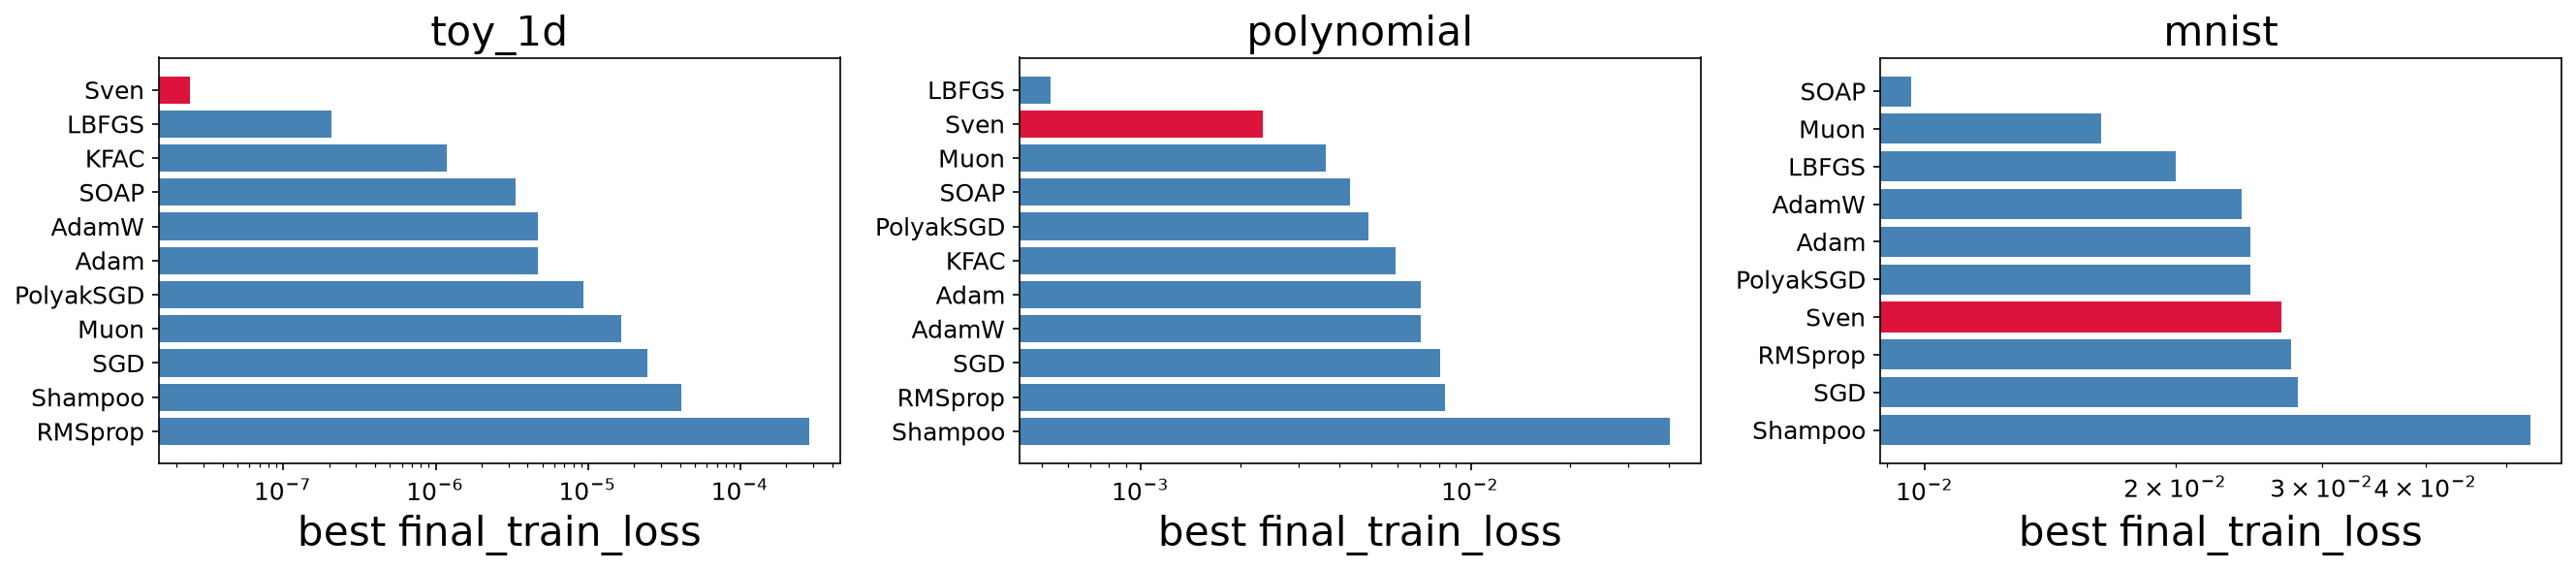

In [3]:
metric = 'final_train_loss'
fig,axes=plt.subplots(1,len(data),figsize=(6*len(data),4.2),squeeze=False)
for ax,(tag,df) in zip(axes[0],data.items()):
    b=best_per_method(df, by=metric).sort_values(metric)
    colors=['crimson' if m=='Sven' else 'steelblue' for m in b['method']]
    ax.barh(b['method'], b[metric], color=colors); ax.set_xscale('log')
    ax.invert_yaxis(); ax.set_title(tag); ax.set_xlabel('best '+metric)
plt.tight_layout(); plt.savefig(PLOT_DIR/'best_loss_by_optimizer.pdf',bbox_inches='tight'); plt.show()

### Table

In [4]:
for tag,df in data.items():
    b=best_per_method(df, by='final_train_loss').sort_values('final_train_loss')
    print(f'== {tag} ==')
    for _,r in b.iterrows(): print(f'  {r.method:10s} train={r.final_train_loss:.3e}  val={r.final_val_loss:.3e}')

== toy_1d ==
  Sven       train=2.427e-08  val=5.899e-08
  LBFGS      train=2.075e-07  val=7.532e-07
  KFAC       train=1.180e-06  val=4.799e-07
  SOAP       train=3.333e-06  val=2.539e-06
  AdamW      train=4.662e-06  val=6.100e-06
  Adam       train=4.662e-06  val=6.100e-06
  PolyakSGD  train=9.380e-06  val=5.977e-06
  Muon       train=1.652e-05  val=1.517e-05
  SGD        train=2.452e-05  val=1.428e-05
  Shampoo    train=4.082e-05  val=4.532e-05
  RMSprop    train=2.825e-04  val=1.095e-05
== polynomial ==
  LBFGS      train=5.301e-04  val=1.701e-03
  Sven       train=2.344e-03  val=1.880e-03
  Muon       train=3.628e-03  val=4.000e-03
  SOAP       train=4.293e-03  val=4.374e-03
  PolyakSGD  train=4.910e-03  val=4.282e-03
  KFAC       train=5.926e-03  val=8.953e-03
  Adam       train=7.075e-03  val=5.718e-03
  AdamW      train=7.075e-03  val=5.718e-03
  SGD        train=8.076e-03  val=6.156e-03
  RMSprop    train=8.351e-03  val=8.397e-03
  Shampoo    train=4.019e-02  val=3.791e-02
==